# Week-3 Day-2

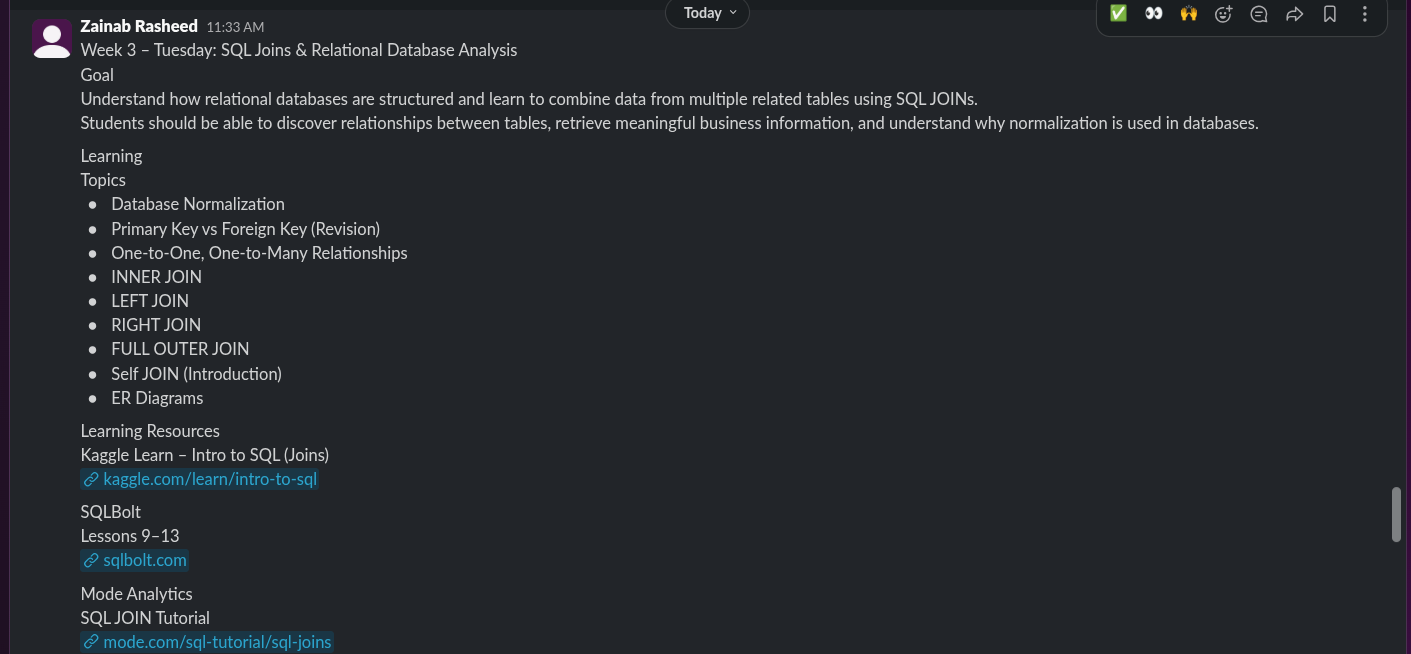

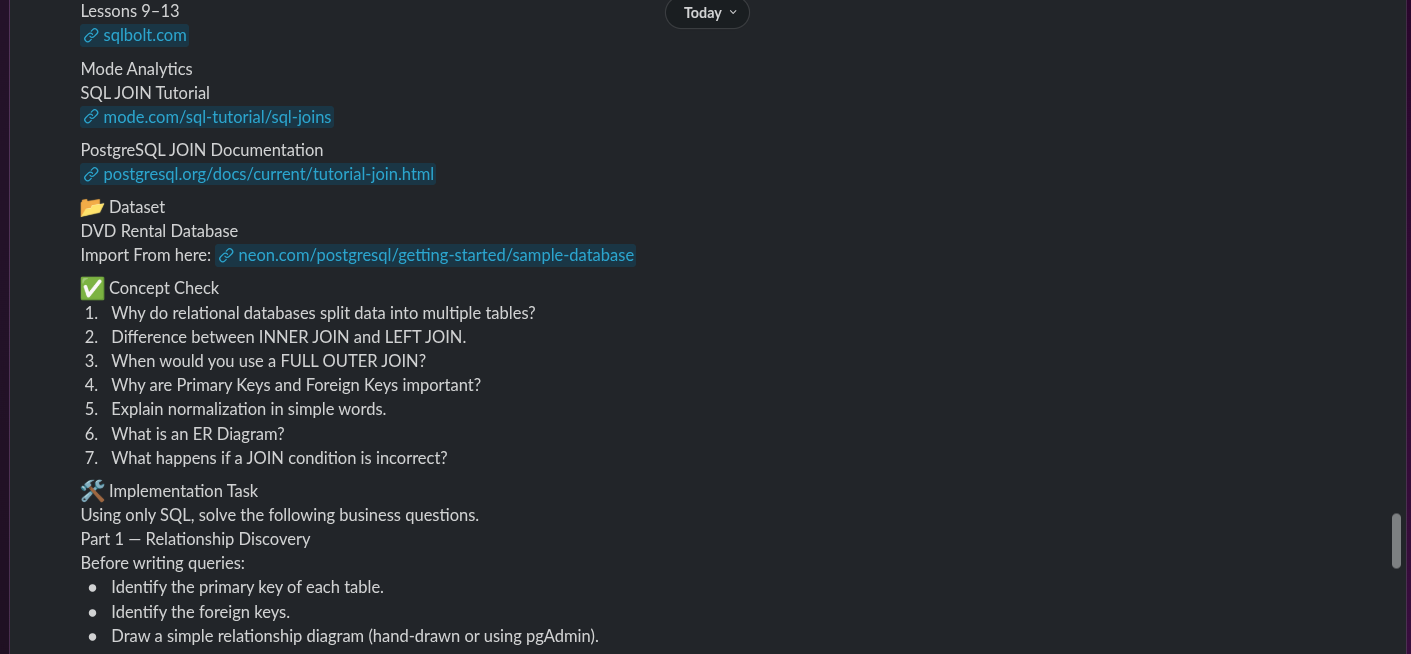

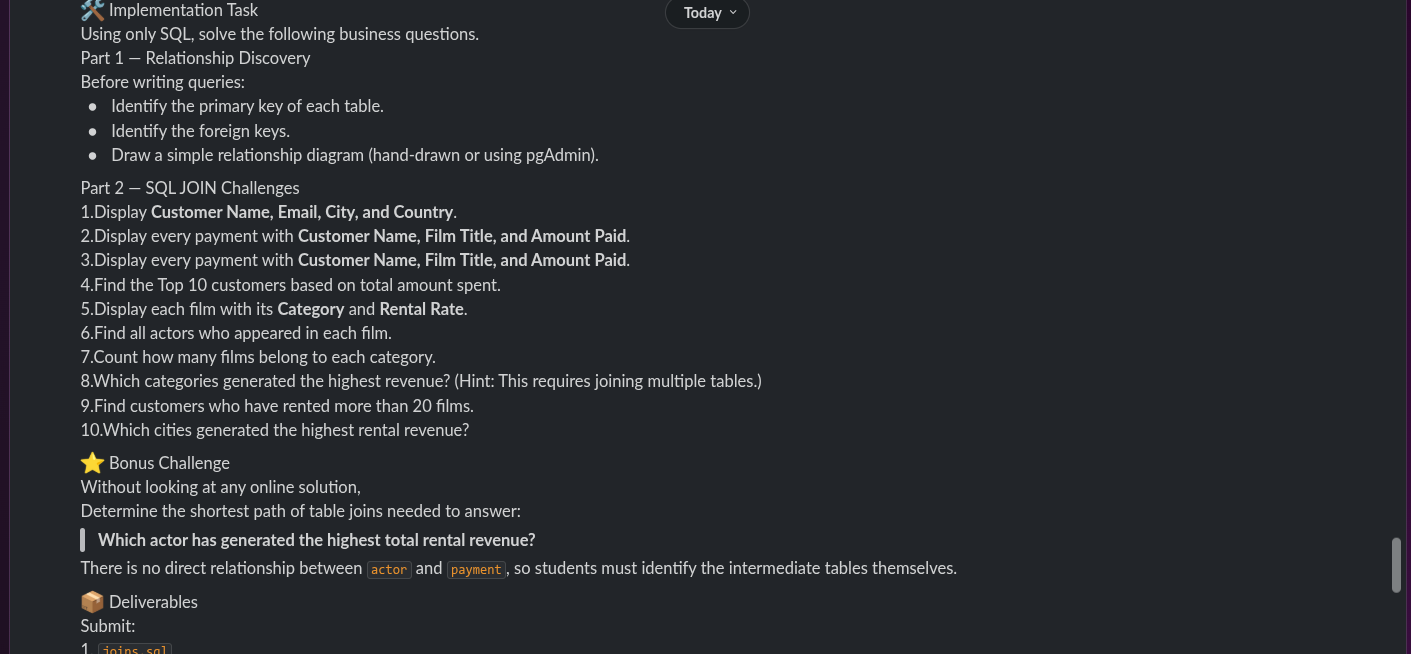

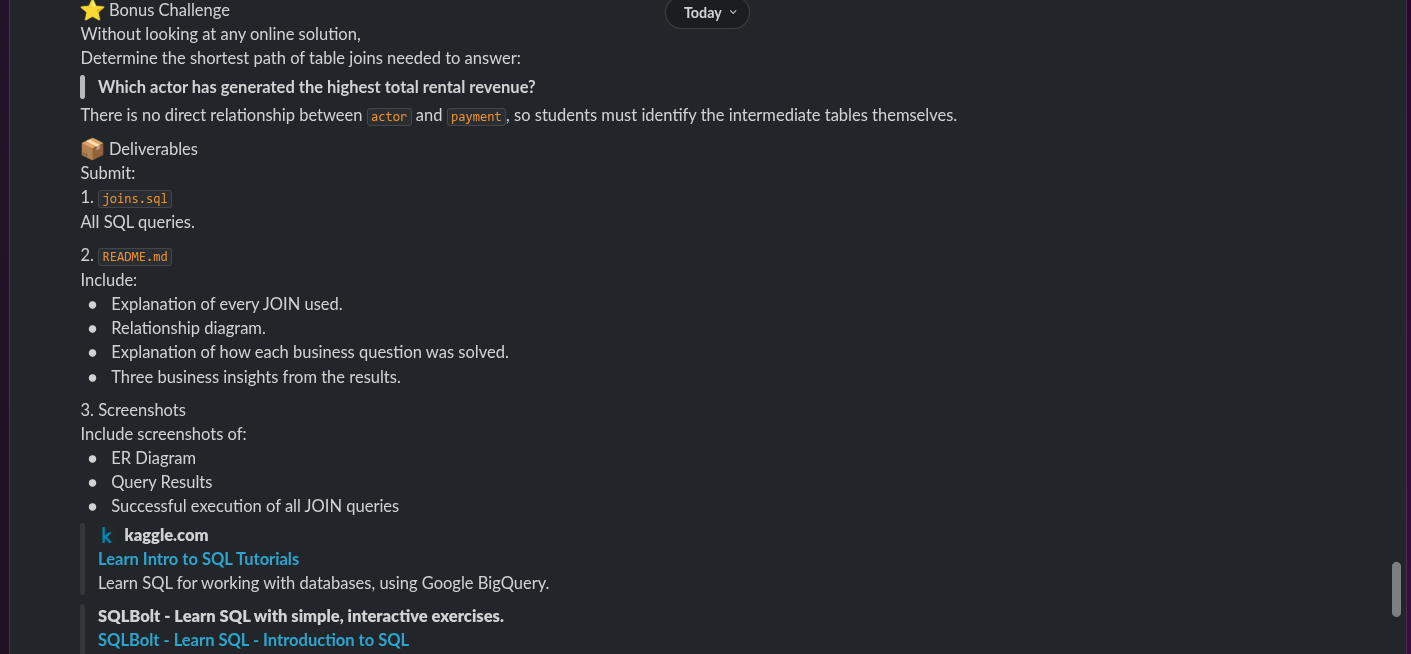

## Part 1 (Topics)

- **Database Normalization**
  - Db Normalization is used to reduce redundancy and data duplication, making your db more robust. The normalization steps go from 0-NF to I think 6-NF, althought 0-NF to 3-NF are probably the most commonly used steps
  - before going into it, I think its best to understand what is a key attribute and what is a nonkey attribute.
  - key attribute: any column that belongs to any candidate key (candidate key is a just a column that is unique throughout the table)
  - non-key attr: any column that belongs to none of the candidate keys, and if its not a candidate key, it cannot be the primary key.
    - 0-NF: the data contains columns containing multiple values, a single cell contains multiple facts
    - 1-NF has the following conditions
      - 1 cell must hold 1 fact (atomicity)
      - there must be a primary key to identify each column
      - there must be no duplicated rows or columns
      - to go from 0-NF to 1-NF, you need to add rows for the repeating values, that would increase the total records in the table and make each cell atomic
    - 2-NF has the following conditions
      - achieve 1-NF
      - eliminate all partial dependency (non key columns depending on a part of the primary key instead of the entire primary key, that is partial dependency)
      - note that a table can only have partial dependency if that table is using a composite primary key, you cannot have a non-key column depending on a part of the primary key column (not the whole) if the primary key column is atomic
      - Just to summarize: partial dependency is when a nonkey attr depends on a part of the primary key (the primary key must be composite for it to have parts). and to remove the partial dependency, we make it depend on the entire primary key, not just that part (by basically destroying the composite key and creating a new table for it),
      - to go from 1-NF to 2-NF, you will need to divide a table into multiple tables, that will remove the partial dependency
      - When you make a Many-to-Many relationship between 2 tables, you will have to make a through table, that through table will have a composite primary key, that is the place where you will mostly run into partial dependencies
    - 3-NF has the following conditions
      - achieve 2-NF
      - Remove all transitive partial dependencies (a non-key column depends on another non-key column and that non-key column depends on the primary key)
      - transitive dependencies are also removed using the same technique, you have to divide an existing table into multiple tables
    - BCNF has the following conditions
      - Achieve 3NF (no nonkey depends on another nonkey and that nonkey depends on primarykey, we must break this chain to achieve 3NF)
      - Every attribute that is a determinant (it determines value of a nonkey attr) must be a candidate key, otherwise BCNF fails
      - You will see a BCNF violation when you have a composite primary key (and nonkey attr depend on the entire composite primary key, not a part of it)
      - to solve BCNF, break the table into two on the composite primary key
    - We also have 4NF, 5NF, and 6NF, but I think the cases for those redundancies become extremely uncommon, and most sites and institutes don't even cover them, so I will just end it here
- **Primary Key VS Foreign Key**
  - This was already covered in the last task from Monday, but lets go again
    - Primmary Key: A key that is completely unique throughout the column and is used to uniquely identify a record in a table.
    - Foreign Key: A key in a table that references the Primary key of another table to form a relationship between two tables.
- **One to One and One to Many Relationships**
  - Again, it was already covered in the last task but lets go again for the sake of completion
    - One-to-One: The primarykey is being referenced by only one instance of the foreign key hence the two tables have a one to one relationship. For instance, consider a school where 1 teacher only teaches 1 class, and we have a teachers and classes table. The classID from the class table will reference exactly 1 teacherID in the teachers table.
    - One-to-Many: The primary key will reference multiple foreign keys, consider an example of a teachers table and a students table. One teacher can teach several students but one student can only be taught by one teacher, that is the business condition. A teacher teaching multiple kids is a many relationship whereas one student being taught by only one teacher is a one relationship, hence forming a one to many connection
- **Inner join**
  - Joins are performed based on foreign key, Inner join is just one type of join, this is when there is an exact match between the two tables and if no records are merged where there is no match. Basically, if you have a teachers and teacher_dpt table, and you do an inner join on the key of teacherId (pk in teachers table and foreign key in teacher_dpt table) and you have a case where a teacher does not belong to any department at all, or a department has zero teachers to reference (same thing said two ways) then those records are completely leftout in this case, only matching ones are merged in inner joins
- **Left join**
  - Consider the same table as above but this time I write the SQL: select xyz from teachers LEFT JOIN teacher_dpt ON teacher.id = teacher_dpt.teacher_id. that would be a left join
  - in a left join, you end up with all the rows of the left table (the one in the from clause) even if that row did not have a match in the right table (the one in the join clause). In the cases where there was no match on the right table, the values of the right table's columns are filled with nulls
- **Right join**
  - Again, lets continue with the same example but this time lets do select xyz from teachers RIGHT JOIN teacher_dpt ON teacher.id = teacher_dpt.teacher_id. that would be a right join
  - the exact opposite of a left join would take place, you get all the values of the right table and none of the non-matching values of the left table. The right columns that you get where they have no match for the left table will be filled with nulls
- **Full outer join**
  - This is basically a complete merge of tables. The SQL I would write would be something like this select xyz from teacher FULL OUTER JOIN teacher_dpt ON teahcer.id = teacher_dpt.teacher_id
  - This would bring in all the columns of the left table and the right table regardless of the match, all the rows where there are no matches will have nulls for those columns. The data would be complete and have everything from both tables (with a whole lot of nulls if you have nonmatching rows)
- **Self join**
  - Self join is a pretty rare case, consider you have some sort of hierarchial table where you have two diff columns but both columns have some sort of matching values. Consider a column called Employees and in that column you have the PK of employee_id and you also have another column called manager_id, manager_id is just showing which employee is the manager of which employee. Hence the employee_id of the manager will be written in the row of that employee. The SQL for an inner join to get the names of the managers would be something like this: select E.name, M.name from Employees as E INNER JOIN Employees as M ON E.employee_id = M.employee_id
  - The above sql would give you two coluumns, both of names, matching the employee to his manager simply
- **ER Diagrams**
  - ERDs are used to visually represent a DB schema, it basically shows the entities (the tables simply) and their traits (the attributes/columns simply) and how the entities interact (relationships). It stands for Entity Relationship Diagram. An E-ERD is an enhanced ERD giving a lot more details and showing OOP principles embedded in the diagram as well like Inheritence and Aggregation

---

## Part 2 (Concept Check)

- Why do relational databases split data into multiple tables?
- Difference between INNER JOIN and LEFT JOIN.
- When would you use a FULL OUTER JOIN?
- Why are Primary Keys and Foreign Keys important?
- Explain normalization in simple words.
- What is an ER Diagram?
- What happens if a JOIN condition is incorrect?

---

## Part 3 (Implementation Task)

Using only SQL, solve the following business questions.
### Part 1 — Relationship Discovery
Before writing queries:


1. **Identify the primary key of each table.**
2. **Identify the foreign keys.**
  - I will answer both 1 and 2 in this table:
    - Table Name: actor (actor_id PK; No FK)
    - Table Name: city (city_id PK; country_id FK from country table)
    - Table Name: country (country_id PK; no FK)
    - Table Name: language (language_id PK; no FK)
    - Table Name: film (film_id PK; language_id FK from language table)
    - Table Name: category (category_id PK; no FK)
    - Table Name: film_category (film_id from film table and category_id from category table forming a Composite Primary Key. Note: this is a through table for a many to many relationship)
    - Table Name: Inventory (inventory_id PK; film_id FK from film table)
    - Table Name: rental (rental_id PK; inventory_id FK from inventory table; customer_id FK from customer table; staff_id FK from staff table)
    - Table Name: film_actor (actor_id from actor table and film_id from film table forming Composite Primary Key. Note: this is anotherr through table for a many to many relationship)
    - Table Name: store (store_id PK; manager_staff_id FK from staff table; address_id FK from address table)
    - Table Name: address (address_id PK; city_id FK from city table)
    - Table Name: customer (customer_id PK; address_id FK from address table)
    - Table Name: staff (staff_id PK; address_id FK from address table)
    - Table Name: payment (payment_id PK; customer_id FK from customer table; staff_id FK from staff table; rental_id FK from rental table)
  - IMPORTANT: staff table also has store_id from store table, I can see that in the ERD in pgadmin, but it doesn't have the normal FK constraint on it for some reason. Same is the case in customer table, there is a store_id but it does not have a FK constraint. And yet again, same is the case in inventory table, there is a store_id with no FK constraint
  - I am ganna ask AI to provide this to me in nice markdown table now so its easier to read

| Table Name | Primary Key (PK) | Foreign Key(s) (FK) | References Parent Table | Notes / Relationship Type |
|---|---|---|---|---|
| actor | actor_id | None | — | Base lookup table for actor details. |
| address | address_id | city_id | city | Standard Address reference. |
| category | category_id | None | — | Film genres (Sci-Fi, Action, etc.). |
| city | city_id | country_id | country | Geographic lookup normalization. |
| country | country_id | None | — | Broadest geographic lookup tier. |
| customer | customer_id | address_id | address | Contains profile information. |
| film | film_id | language_id | language | Movie metadata attributes. |
| film_actor | (actor_id, film_id) | actor_id film_id | actor film | Composite PK; Junction table managing Many-to-Many connection. |
| film_category | (film_id, category_id) | film_id category_id | film category | Composite PK; Junction table managing Many-to-Many connection. |
| inventory | inventory_id | film_id | film | Physical stock items available in stores. |
| language | language_id | None | — | Spoken/Subtitled language lookups. |
| payment | payment_id | customer_id staff_id rental_id | customer staff rental | Transaction records log table. |
| rental | rental_id | inventory_id customer_id staff_id | inventory customer staff | Core operational process tracking table. |
| staff | staff_id | address_id | address | Internal team profiles. |
| store | store_id | manager_staff_id address_id | staff address | Physical retail locations. |

------------------------------
1. **Draw a simple relationship diagram (hand-drawn or using pgAdmin).**

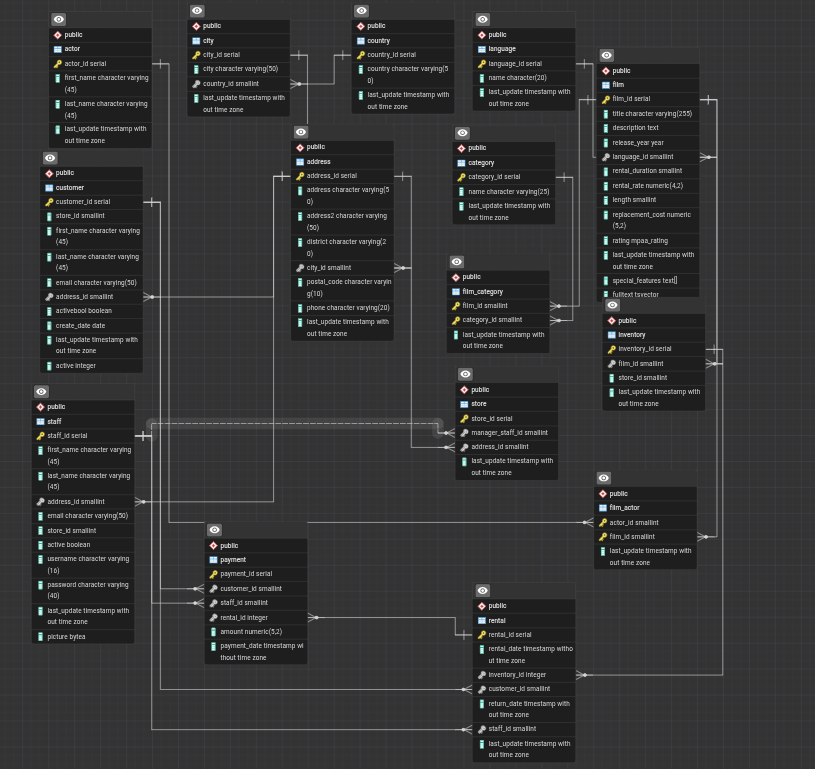



---

### Part 2 — SQL JOIN Challenges

- You can view SQL-FIles/joins.sql and also screenshots folder for this task's verification

#### 1. Display Customer Name, Email, City, and Country.

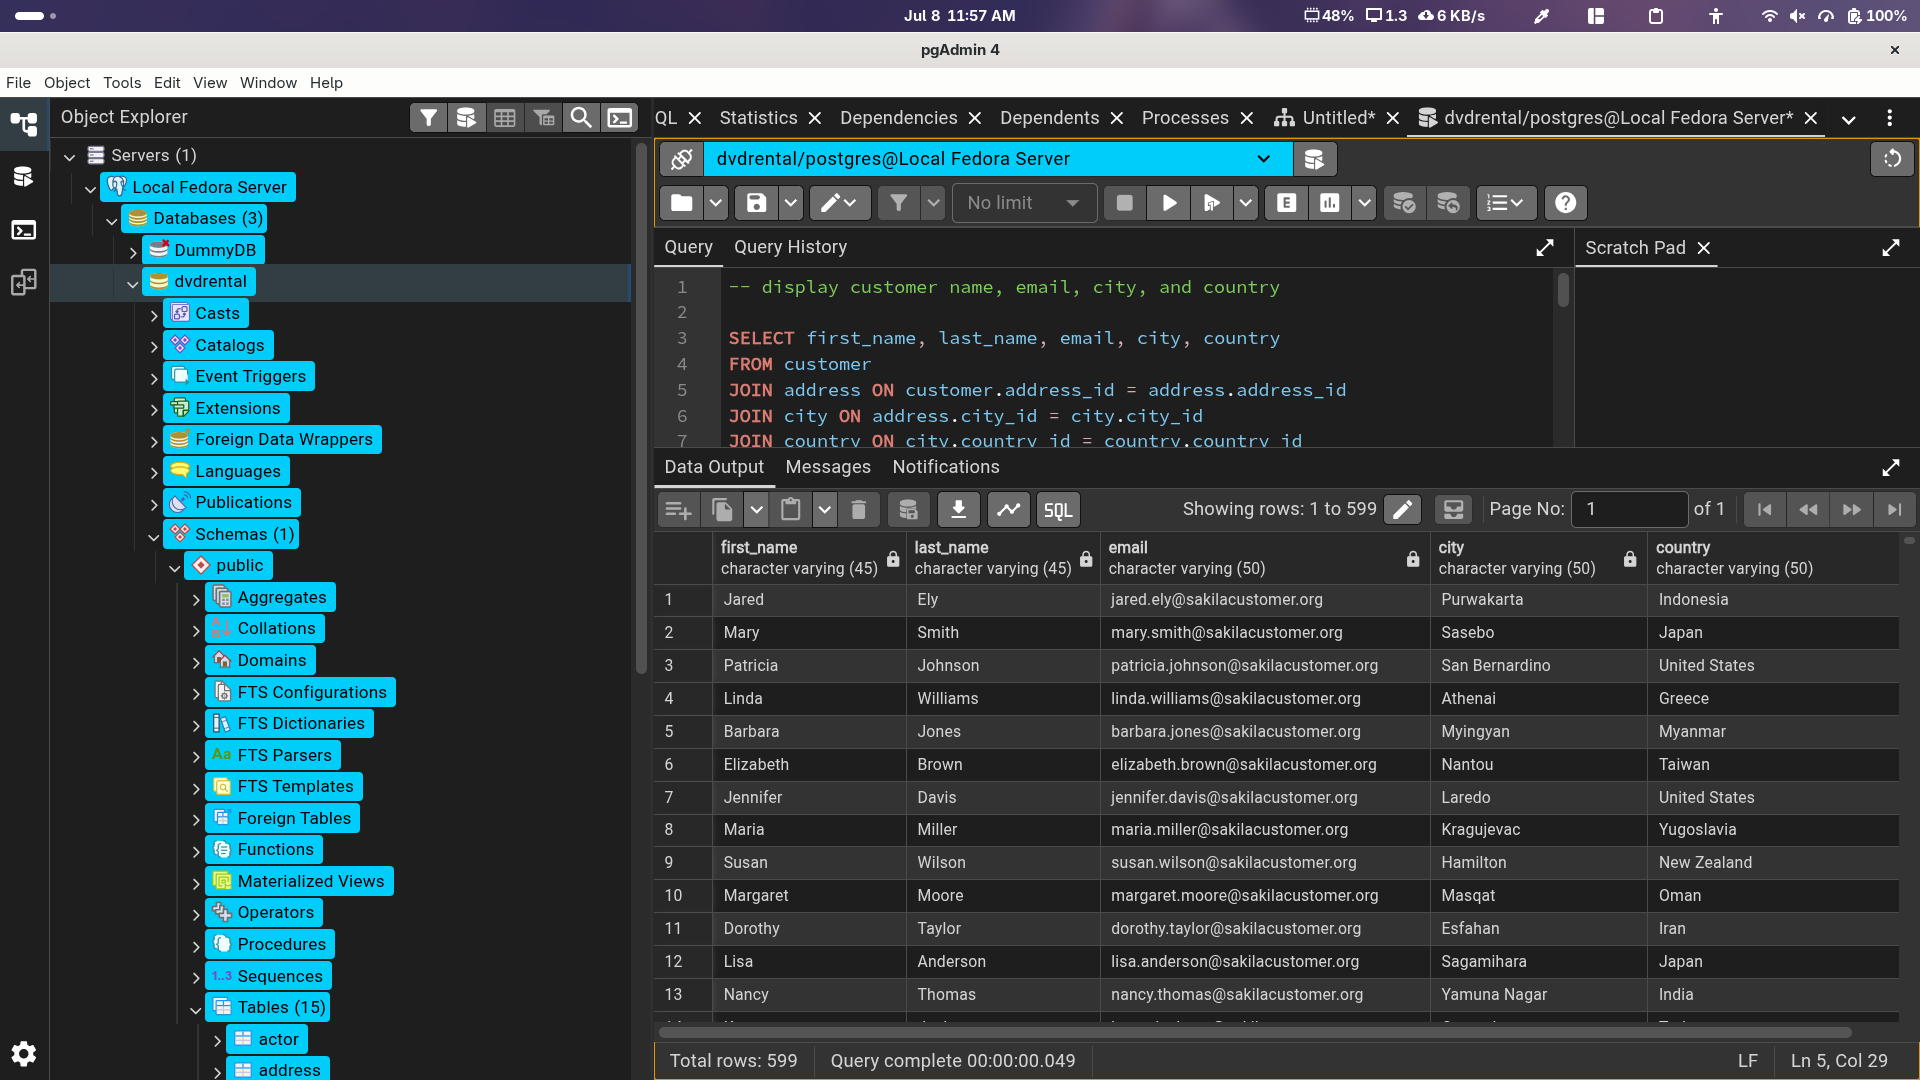

#### 2. Display every payment with Customer Name, Film Title, and Amount Paid.

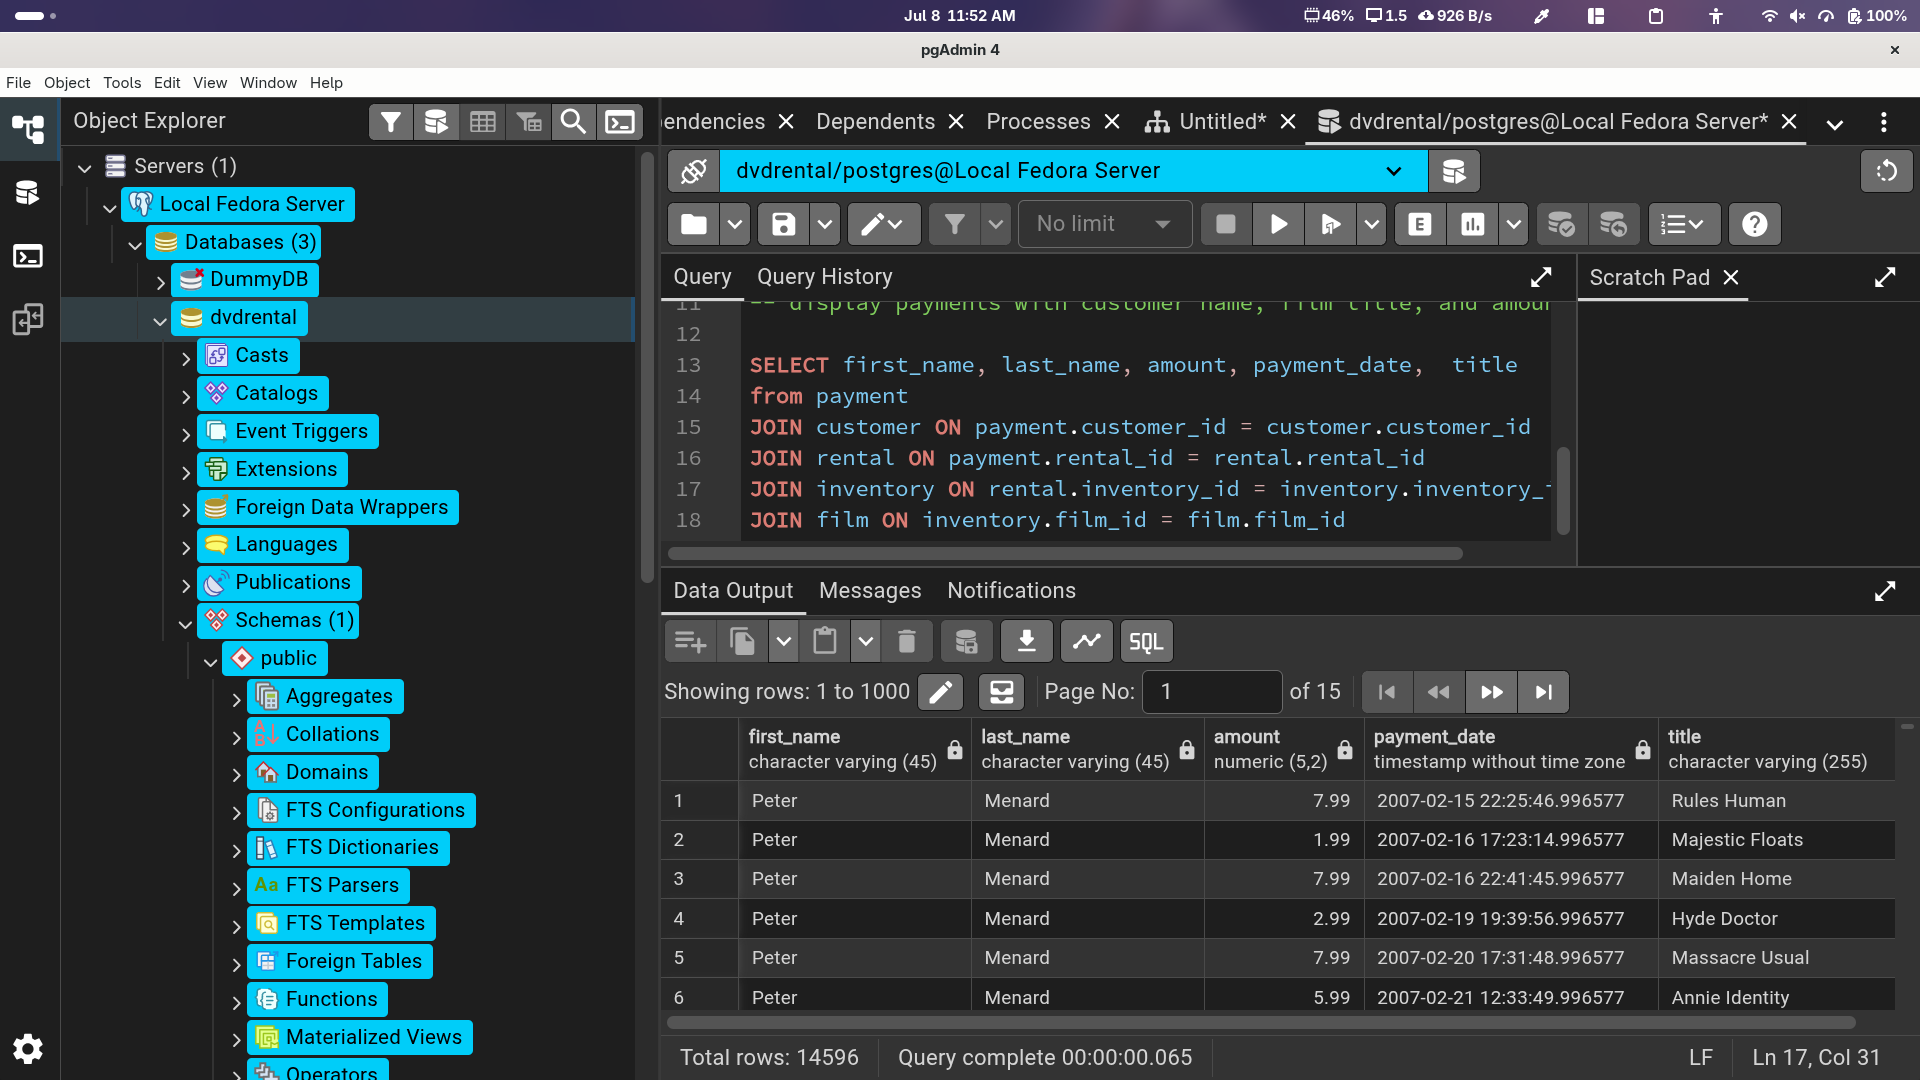

#### 3. Display every payment with Customer Name, Film Title, and Amount Paid.

- this is literally the same as above, so already answered

#### 4. Find the Top 10 customers based on total amount spent.

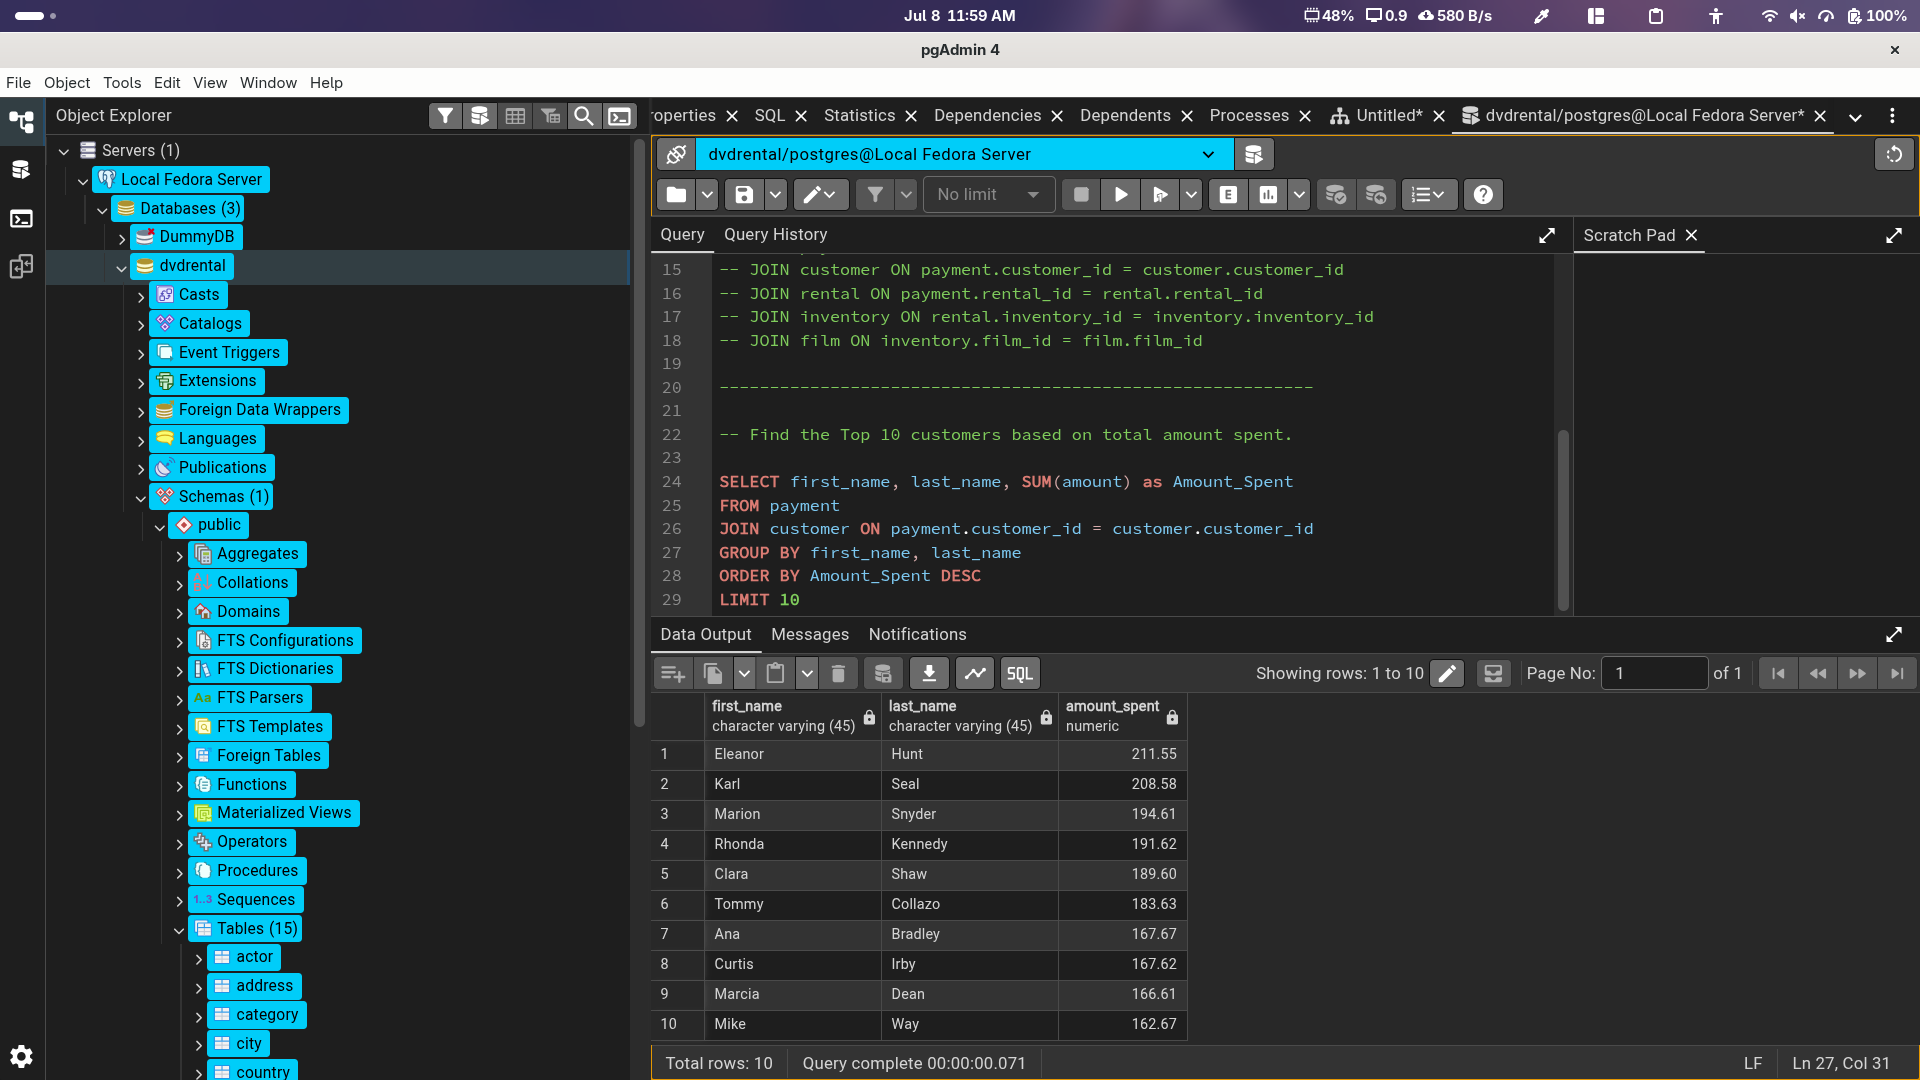

#### 5. Display each film with its Category and Rental Rate.

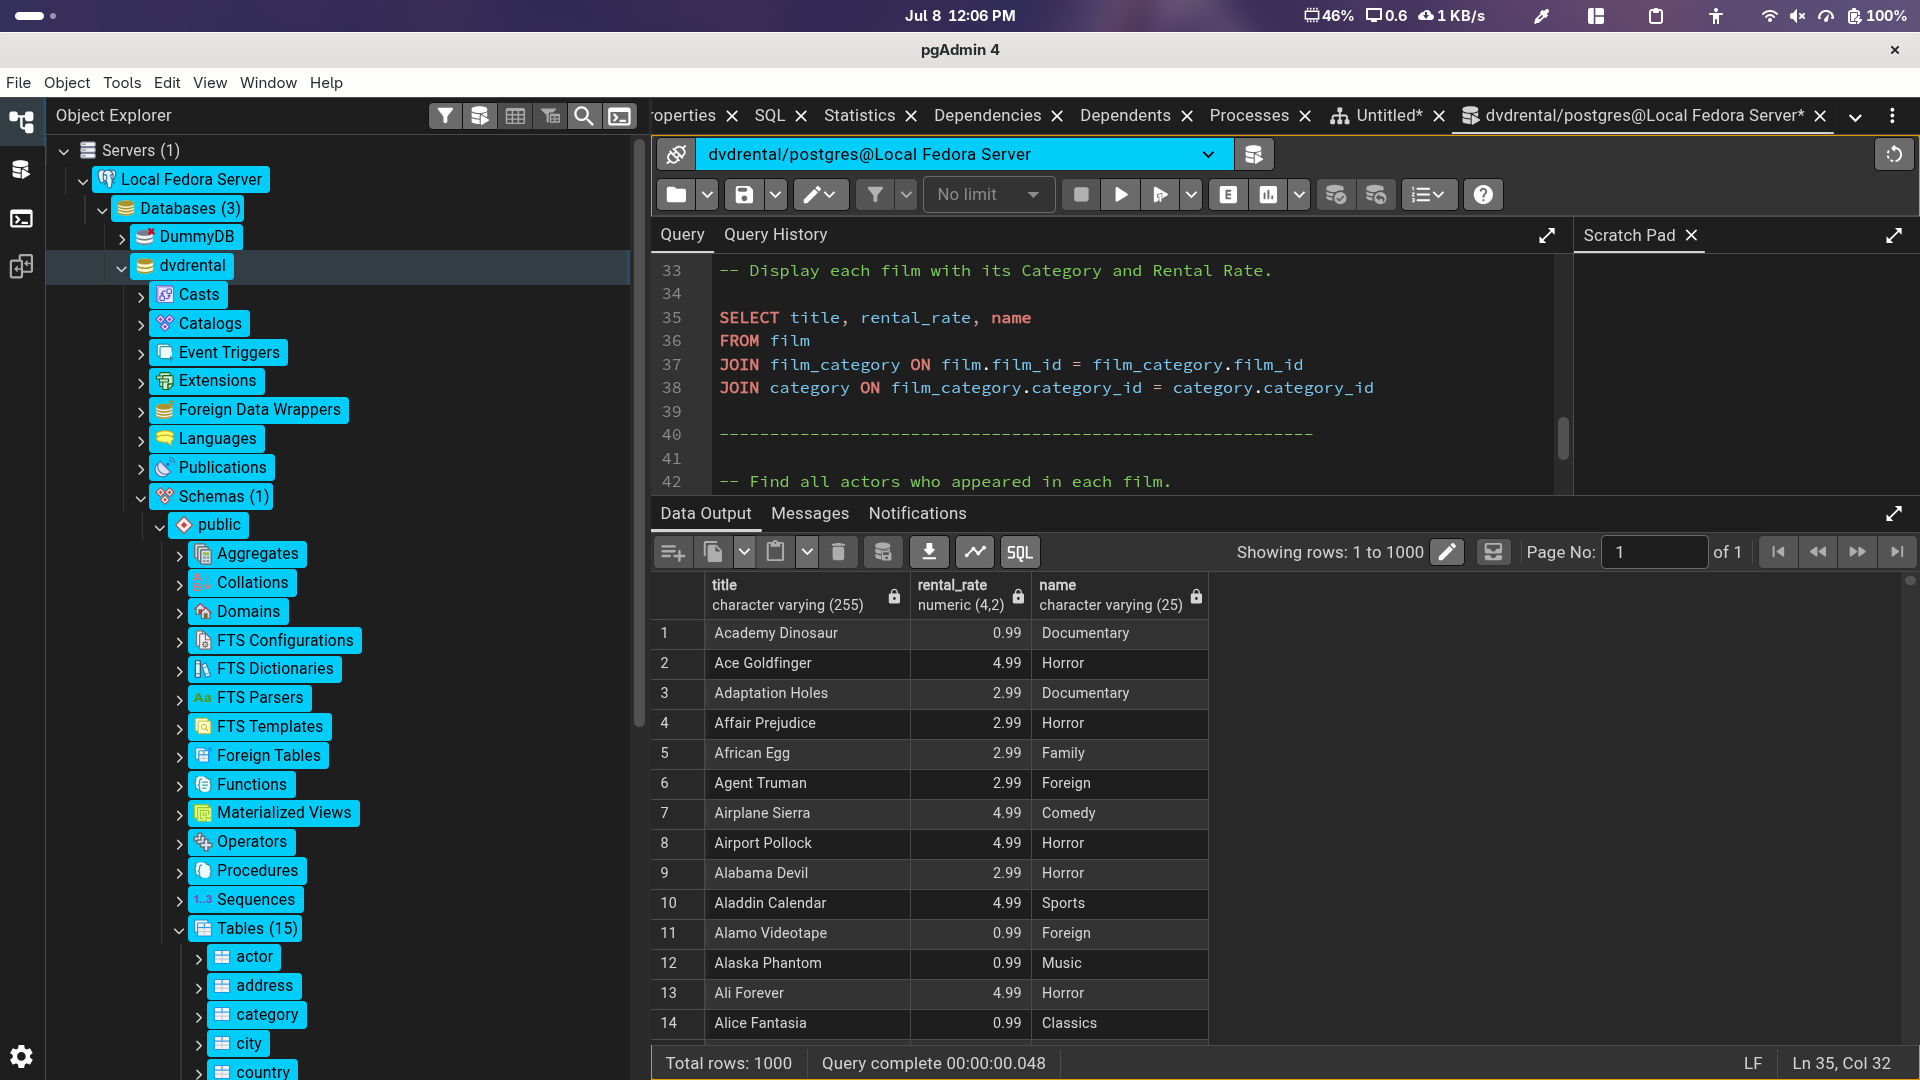

#### 6. Find all actors who appeared in each film.

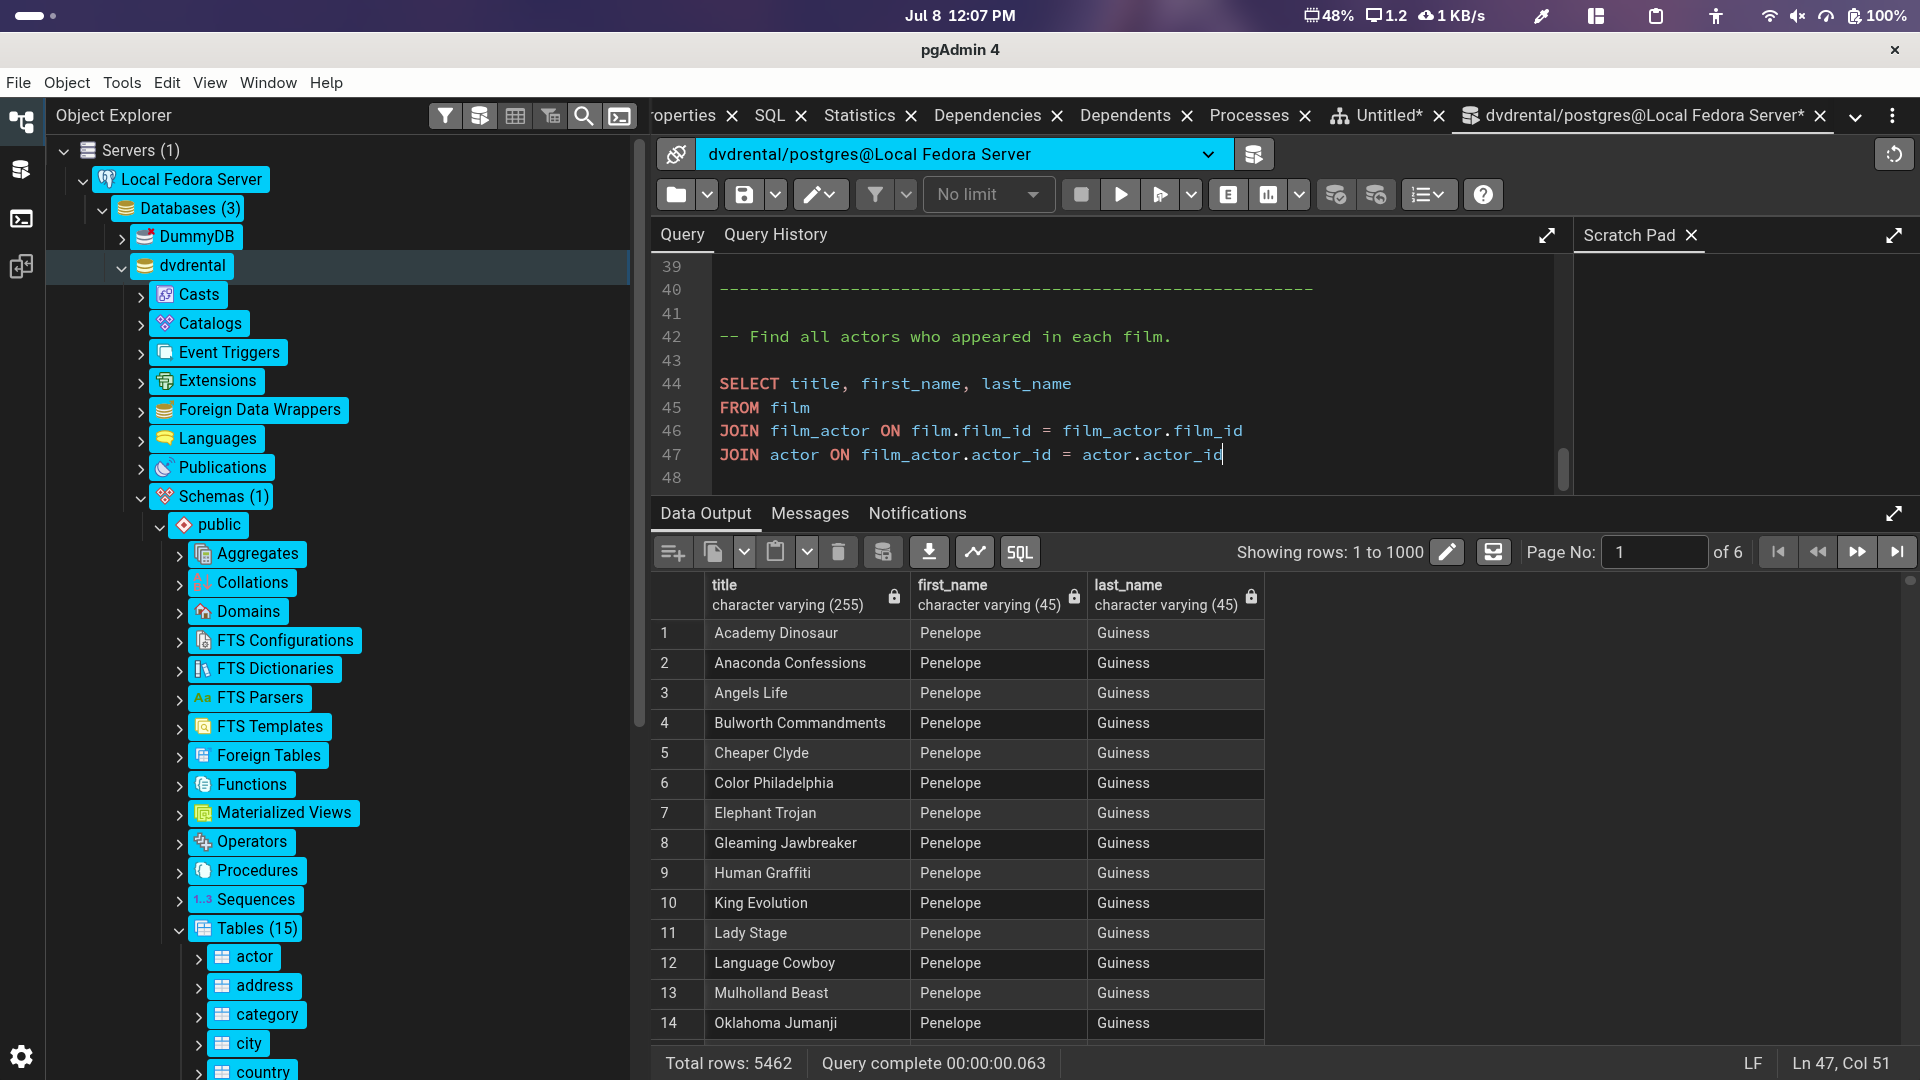

#### 7. Count how many films belong to each category.

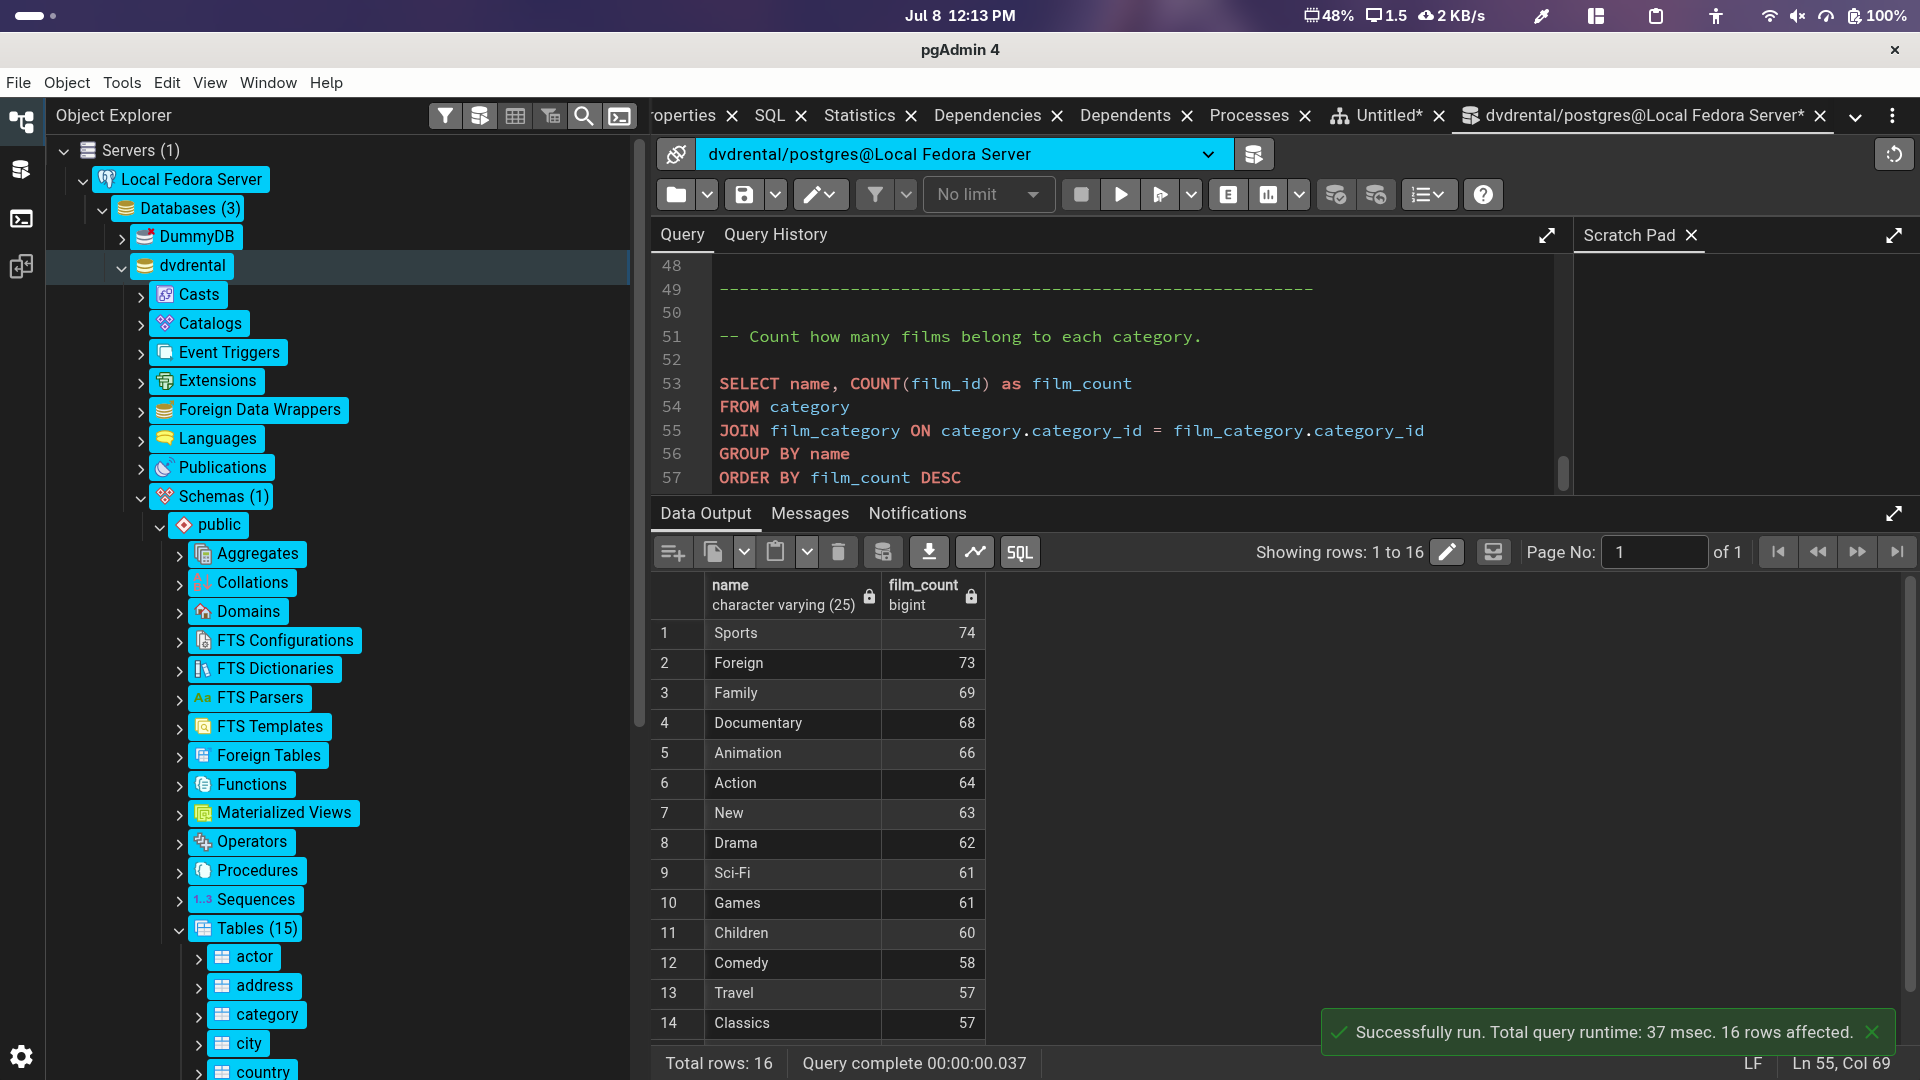

#### 8. Which categories generated the highest revenue? (Hint: This requires joining multiple tables.)

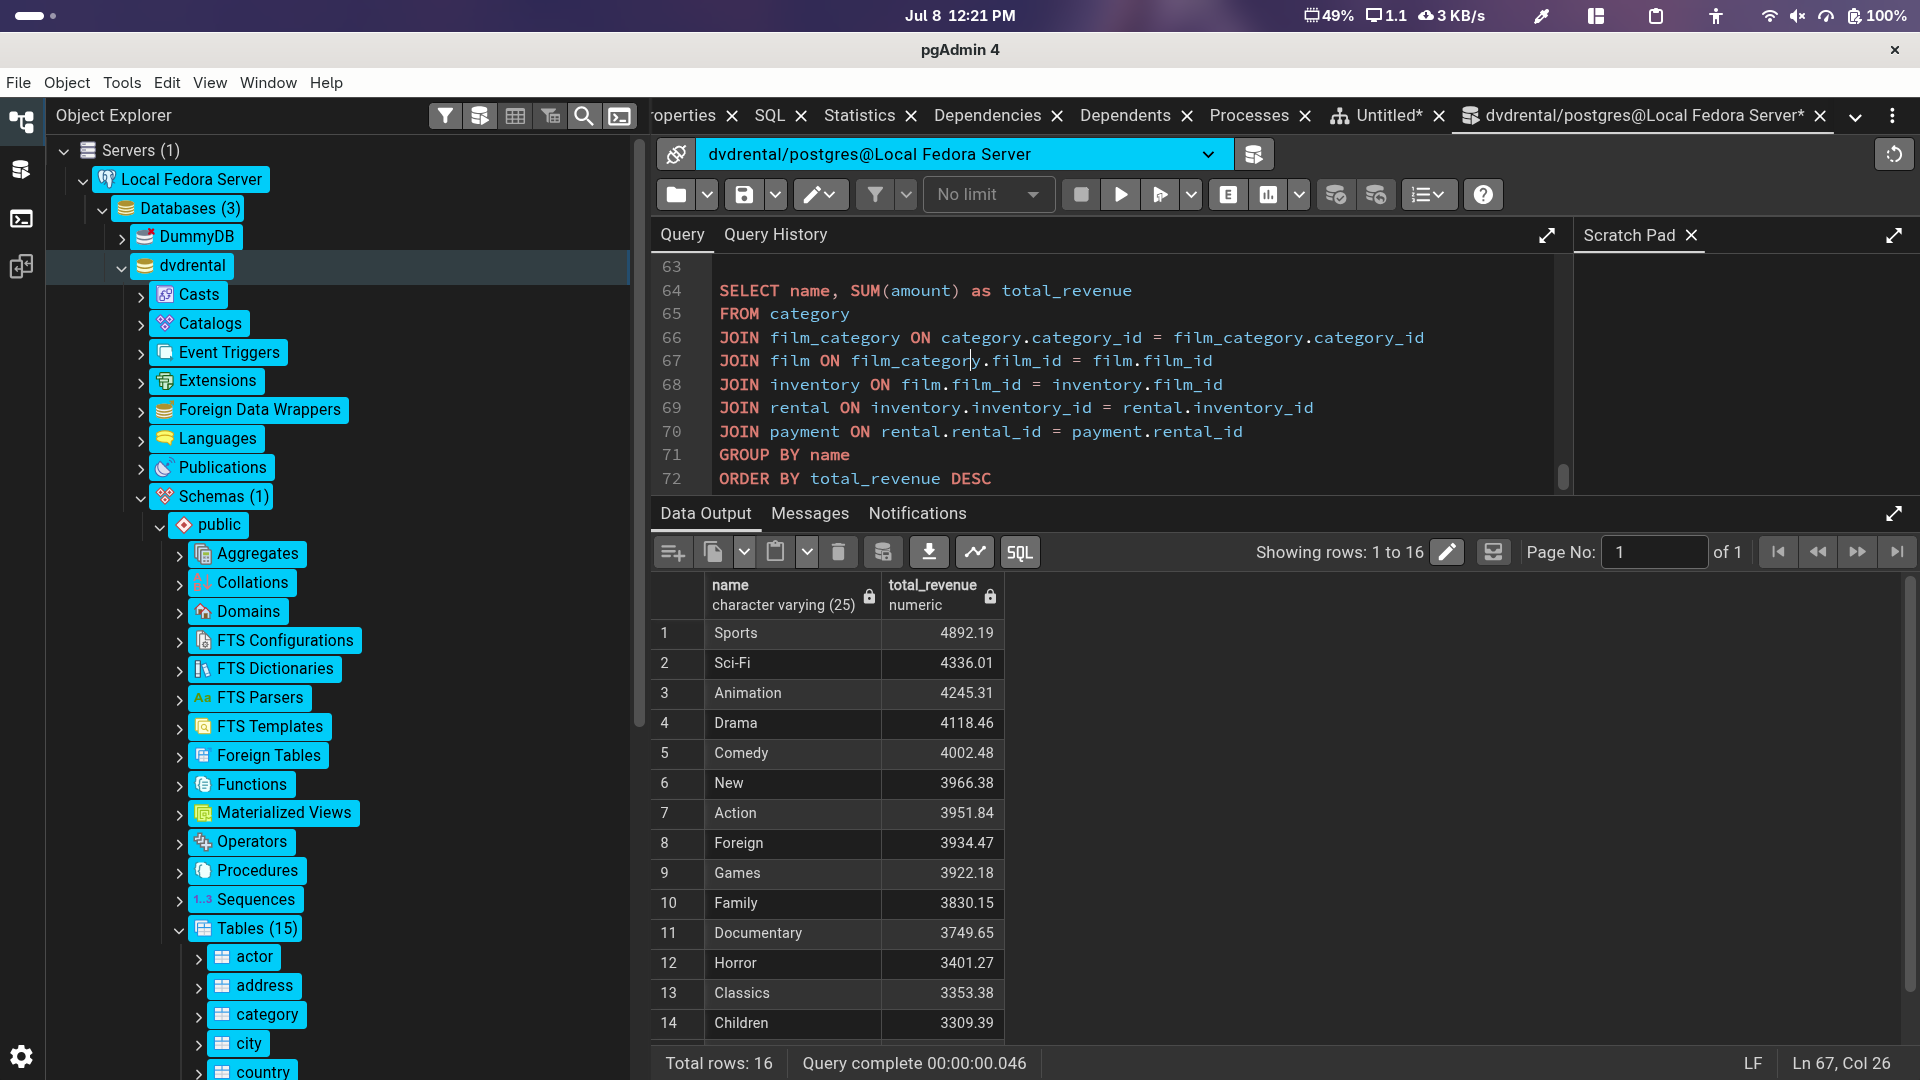

#### 9. Find customers who have rented more than 20 films.

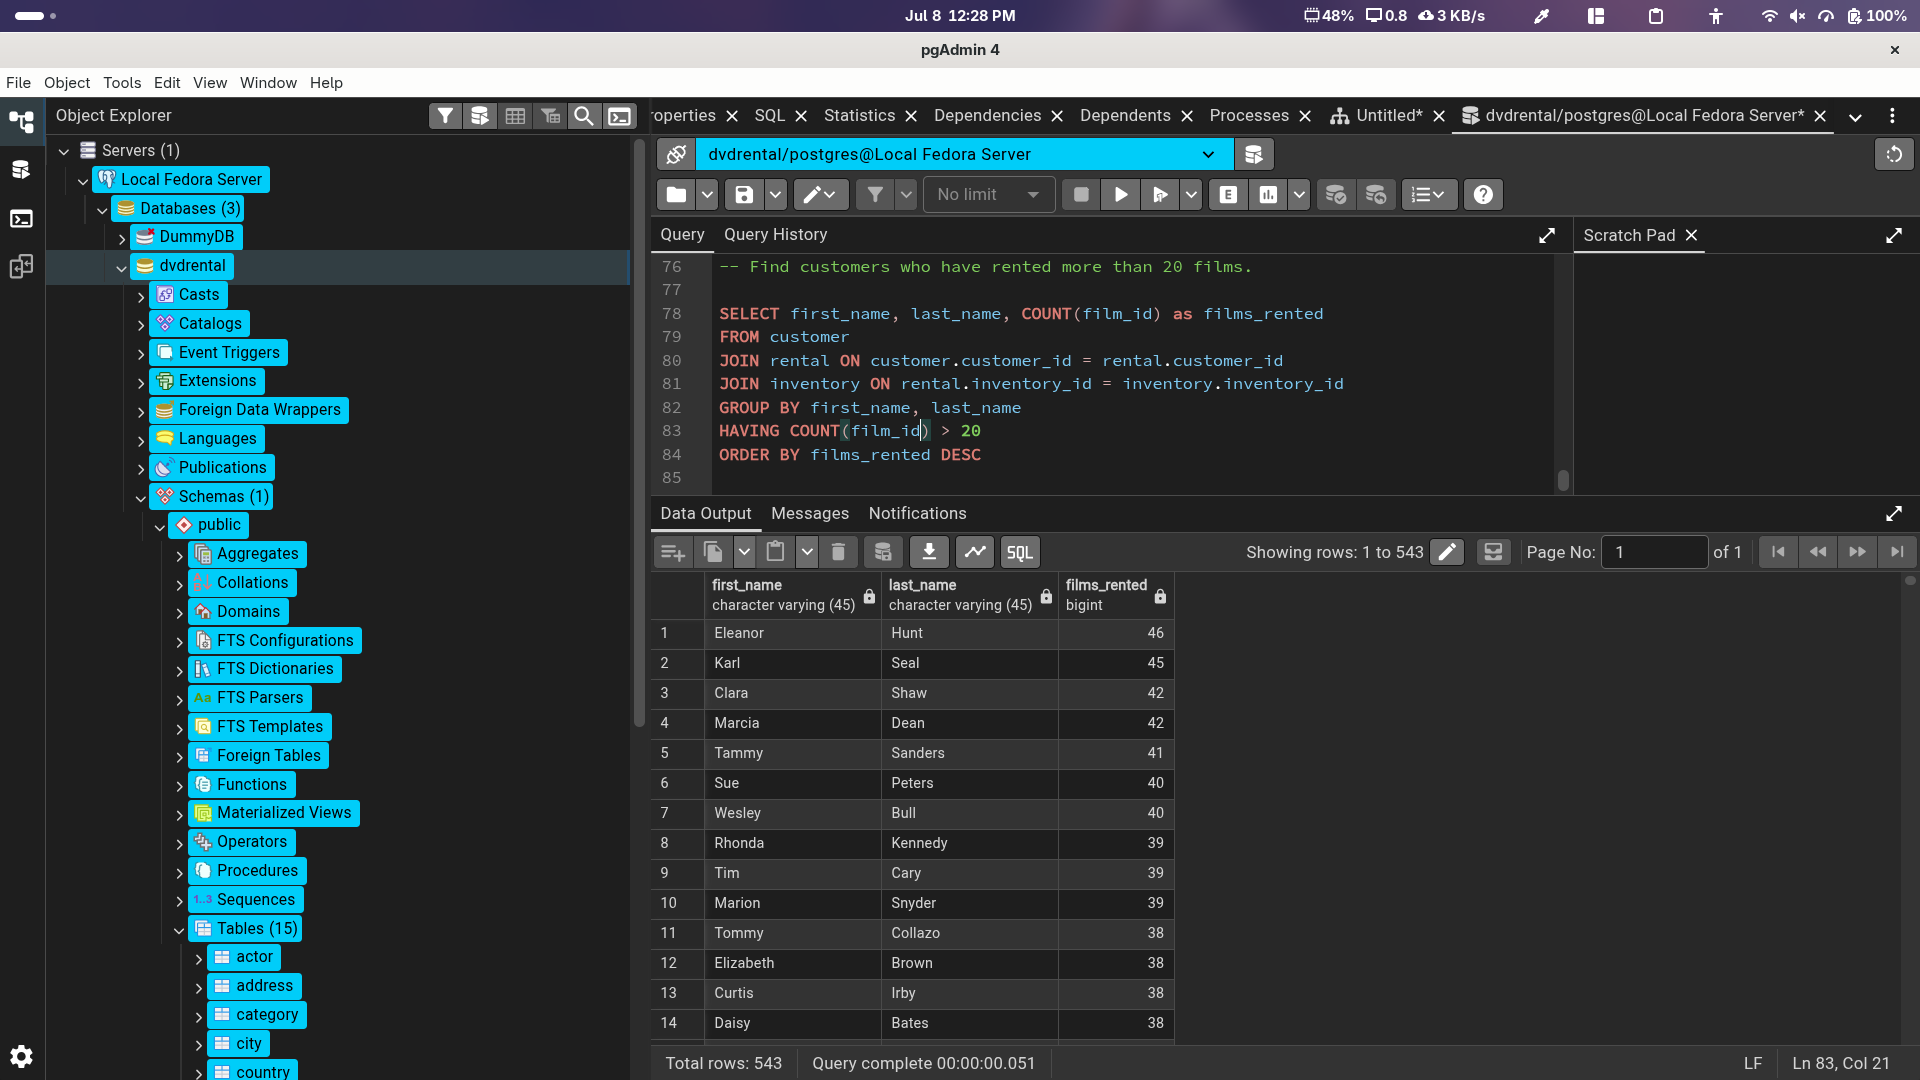

#### 10.  Which cities generated the highest rental revenue?

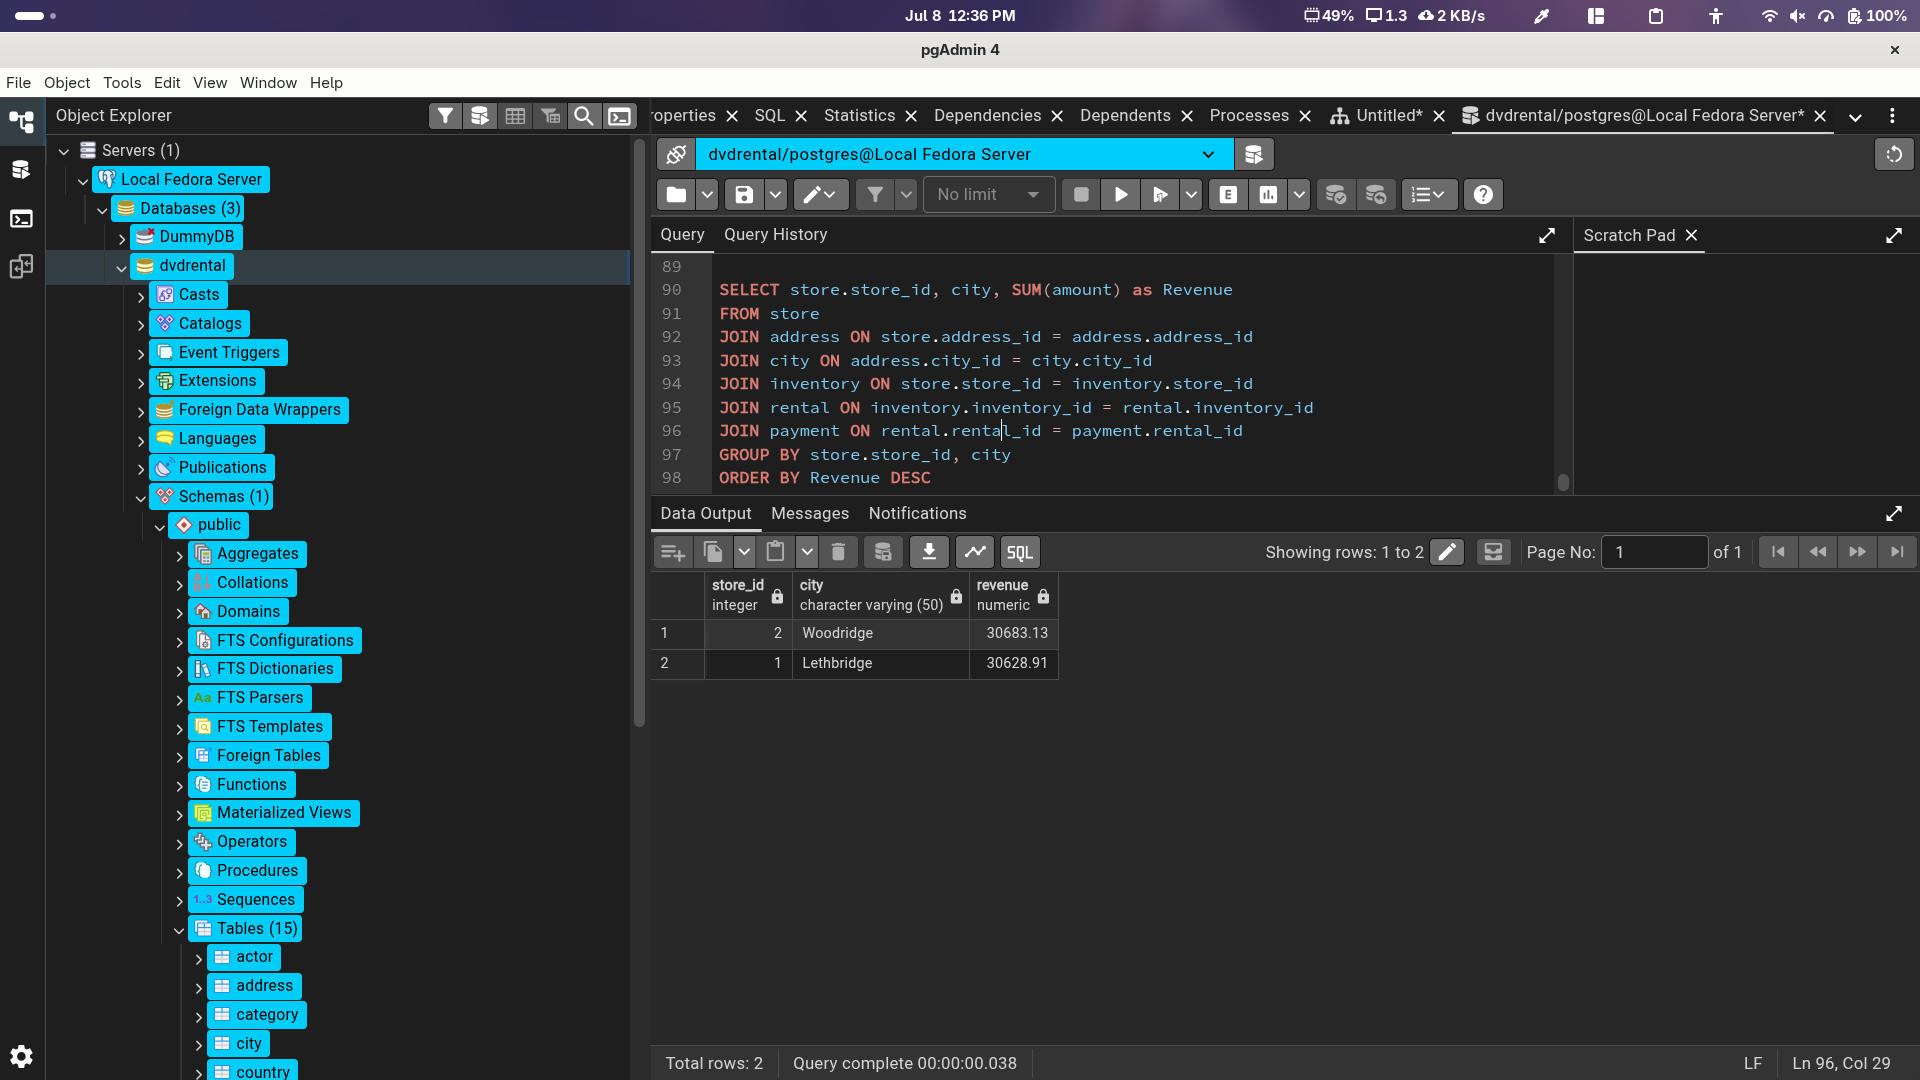


---

### Bonus Task 
- Without looking at any online solution,
- Determine the shortest path of table joins needed to answer:
- Which actor has generated the highest total rental revenue?
- There is no direct relationship between actor and payment, so students must identify the intermediate tables themselves.


#### **Answer**

- for the first one, which actor has generateed the most revenue:
  - the naive approach is **actor->film_actor->film->inventory->rental->payment**. that is a total of 6 tables
  - andddd, well, I failed to find anything better than this so that is my best answer

---

## Part 4 (Deliverables)

### 1. **joins.sql**

- view Week-3/Day-2/SQL-Files/joins.sql

### 2. **readme.md**

IMPORTANT: The 4 points below are already covered in this notebook for the most part, but I did AI a readme quickly and pasted that into readme.md as well just for completion

  - Explanation of every JOIN used.
  - Relationship diagram.
  - Explanation of how each business question was solved.
  - Three business insights from the results.
### 3. **screenshots**

- Please visit Week-3/Day-2/screenshots to view all the screenshots

  - ER Diagram
  - Query Results
  - Successful execution of all join queries

---